# hn22 + hn23 + hn24 통합 EDA
성인(19세 이상) | 전처리 전 원본 기준

**타겟 코드북**: 1=유병 / 8(해당없음)=정상 / 0·9=제외

## 0. 데이터 로드

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib import rc
from scipy import stats
import pyreadstat
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams["axes.unicode_minus"] = False
rc("font", family="AppleGothic")

USE_COLS_SAS = [
    "ID","sex","age","occp","HE_ht","HE_wt","HE_BMI","sm_presnt",
    "BD1_11","BD2_1",
    "HE_HPfh1","HE_HPfh2","HE_HPfh3",
    "HE_DMfh1","HE_DMfh2","HE_DMfh3",
    "HE_HLfh1","HE_HLfh2","HE_HLfh3",
    "BE3_31","BE5_1",
    "DI1_pr","DE1_pr","DI2_pr","HE_obe",
]
COL_RENAME = {
    "sex":"성별","age":"나이","occp":"직업","HE_ht":"키","HE_wt":"체중","HE_BMI":"BMI",
    "sm_presnt":"현재흡연","BD1_11":"음주빈도","BD2_1":"음주량",
    "HE_HPfh1":"고혈압가족력_부","HE_HPfh2":"고혈압가족력_모","HE_HPfh3":"고혈압가족력_형제",
    "HE_DMfh1":"당뇨가족력_부","HE_DMfh2":"당뇨가족력_모","HE_DMfh3":"당뇨가족력_형제",
    "HE_HLfh1":"고지혈증가족력_부","HE_HLfh2":"고지혈증가족력_모","HE_HLfh3":"고지혈증가족력_형제",
    "BE3_31":"걷기일수","BE5_1":"근력운동일수",
    "DI1_pr":"고혈압유병","DE1_pr":"당뇨유병","DI2_pr":"이상지질혈증유병","HE_obe":"비만단계",
}
INT_COLS = [
    "성별","나이","직업","현재흡연","음주빈도","음주량","걷기일수","근력운동일수",
    "고혈압유병","당뇨유병","이상지질혈증유병","비만단계",
    "고혈압가족력_부","고혈압가족력_모","고혈압가족력_형제",
    "당뇨가족력_부","당뇨가족력_모","당뇨가족력_형제",
    "고지혈증가족력_부","고지혈증가족력_모","고지혈증가족력_형제",
]

# ── 경로 수정 ──────────────────────────────────────────
DATA_DIR = "/Users/admin/PycharmProjects/AH_03_03/ai_worker/data"

PATHS = {
    2022: f"{DATA_DIR}/hn22_all.sas7bdat",
    2023: f"{DATA_DIR}/hn23_all.sas7bdat",
    2024: f"{DATA_DIR}/hn24_all.sas7bdat",
}
# ──────────────────────────────────────────────────────

dfs = []
for year, path in PATHS.items():
    df_tmp, _ = pyreadstat.read_sas7bdat(path, usecols=USE_COLS_SAS)
    df_tmp = df_tmp.rename(columns=COL_RENAME)
    for c in INT_COLS:
        if c in df_tmp.columns:
            df_tmp[c] = pd.to_numeric(df_tmp[c], errors="coerce")
    df_tmp = df_tmp[df_tmp["나이"] >= 19].reset_index(drop=True)
    df_tmp = df_tmp.drop(columns=["ID"])
    df_tmp["연도"] = year
    dfs.append(df_tmp)
    print(f"hn{year} 로드 완료 | shape: {df_tmp.shape}")

# hn21 당뇨 행 추가
df21 = pd.read_csv(f"{DATA_DIR}/hn21_diabetes_DE1pr.csv", usecols=USE_COLS_SAS)
df21 = df21.rename(columns=COL_RENAME)
for c in INT_COLS:
    if c in df21.columns:
        df21[c] = pd.to_numeric(df21[c], errors="coerce")
df21 = df21[df21["나이"] >= 19].reset_index(drop=True)
df21 = df21.drop(columns=["ID"], errors="ignore")
df21["연도"] = 2021
for col in ["고혈압유병","당뇨유병","이상지질혈증유병"]:
    df21[col] = df21[col].map({1.0:1, 1:1, 8.0:0, 8:0})

dfs.append(df21)
df = pd.concat(dfs, ignore_index=True)

# 타겟 이진화: 1=유병 / 8→0=정상 / 0·9→NaN
for col in ["고혈압유병","당뇨유병","이상지질혈증유병"]:
    df[col] = df[col].map({1.0:1, 1:1, 8.0:0, 8:0})

print(f"통합 shape: {df.shape}")
print(f"연도별 샘플: {df['연도'].value_counts().sort_index().to_dict()}")
df.head()

hn2022 로드 완료 | shape: (5322, 25)
hn2023 로드 완료 | shape: (5907, 25)
hn2024 로드 완료 | shape: (6033, 25)
통합 shape: (17927, 25)
연도별 샘플: {2021: 665, 2022: 5322, 2023: 5907, 2024: 6033}


,성별,나이,직업,고혈압유병,이상지질혈증유병,당뇨유병,음주빈도,음주량,현재흡연,걷기일수,...,고지혈증가족력_모,고지혈증가족력_형제,당뇨가족력_부,당뇨가족력_모,당뇨가족력_형제,키,체중,BMI,비만단계,연도
0,2.0,56.0,7.0,1.0,0.0,0.0,1.0,8.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,151.2,60.6,26.507517,4.0,2022
1,1.0,30.0,3.0,0.0,0.0,0.0,3.0,2.0,0.0,8.0,...,0.0,0.0,1.0,0.0,0.0,174.1,82.3,27.152029,4.0,2022
2,2.0,25.0,7.0,0.0,0.0,0.0,4.0,1.0,0.0,8.0,...,1.0,0.0,1.0,0.0,0.0,166.4,59.0,21.308131,2.0,2022
3,1.0,66.0,7.0,0.0,1.0,0.0,3.0,2.0,0.0,8.0,...,0.0,0.0,0.0,0.0,0.0,168.7,67.1,23.577207,3.0,2022
4,2.0,62.0,6.0,0.0,1.0,0.0,2.0,1.0,0.0,8.0,...,0.0,1.0,0.0,0.0,1.0,157.1,53.9,21.839183,2.0,2022


## 1. 기본 통계량

In [22]:
cont_cols = ["나이","키","체중","BMI"]
summary = pd.DataFrame({
    "N":        df[cont_cols].count(),
    "결측수":    df[cont_cols].isnull().sum(),
    "결측률(%)": (df[cont_cols].isnull().sum()/len(df)*100).round(1),
    "평균":      df[cont_cols].mean().round(2),
    "중앙값":    df[cont_cols].median().round(2),
    "표준편차":  df[cont_cols].std().round(2),
    "최솟값":    df[cont_cols].min().round(2),
    "최댓값":    df[cont_cols].max().round(2),
    "왜도":      df[cont_cols].skew().round(3),
    "첨도":      df[cont_cols].kurt().round(3),
})
print("=== 연속형 변수 기술통계 ===")
print(summary.T)

=== 연속형 변수 기술통계 ===
               나이          키         체중        BMI
N       17927.000  17583.000  17809.000  17579.000
결측수         0.000    344.000    118.000    348.000
결측률(%)      0.000      1.900      0.700      1.900
평균         54.320    163.340     64.660     24.130
중앙값        56.000    162.900     62.900     23.780
표준편차       16.970      9.300     13.230      3.780
최솟값        19.000    127.900     25.000     12.070
최댓값        80.000    194.000    147.000     48.680
왜도         -0.293      0.107      0.876      0.789
첨도         -0.948     -0.388      1.450      1.683


## 2. 연도별 샘플 분포

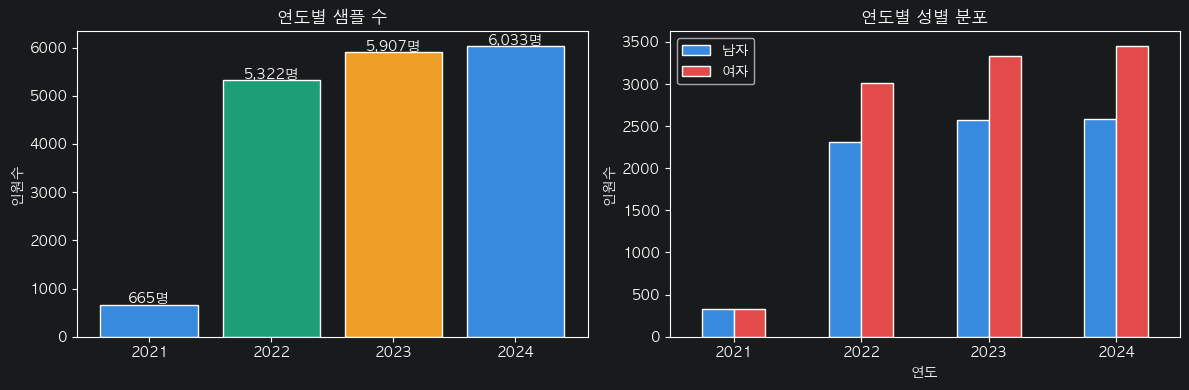

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = df["연도"].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=["#378ADD","#1D9E75","#EF9F27"], edgecolor="white")
axes[0].set_title("연도별 샘플 수"); axes[0].set_ylabel("인원수")
for i, (idx, val) in enumerate(vc.items()):
    axes[0].text(i, val+30, f"{val:,}명", ha="center", fontsize=10)

gender_ct = df.groupby(["연도","성별"]).size().unstack(fill_value=0)
gender_ct.columns = ["남자","여자"]
gender_ct.plot(kind="bar", ax=axes[1], color=["#378ADD","#E24B4A"], edgecolor="white", rot=0)
axes[1].set_title("연도별 성별 분포"); axes[1].set_ylabel("인원수"); axes[1].legend()

plt.tight_layout(); plt.show()

## 3. Y값(타겟) 분포
> **0=정상(해당없음) / 1=유병 / NaN=치료안함·무응답(제외)**

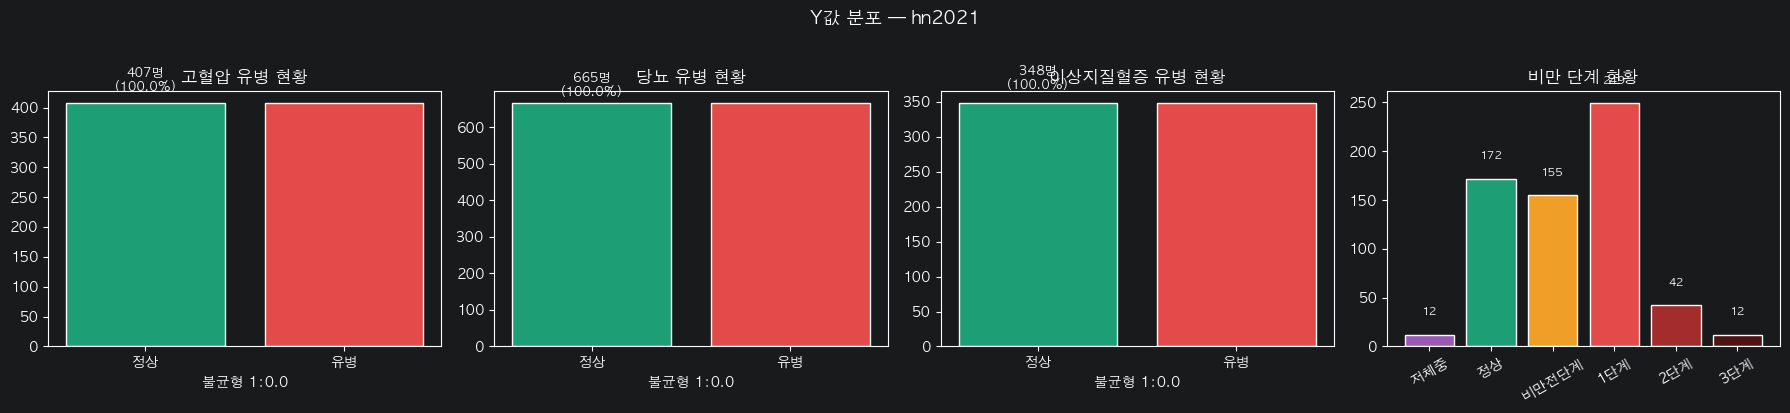

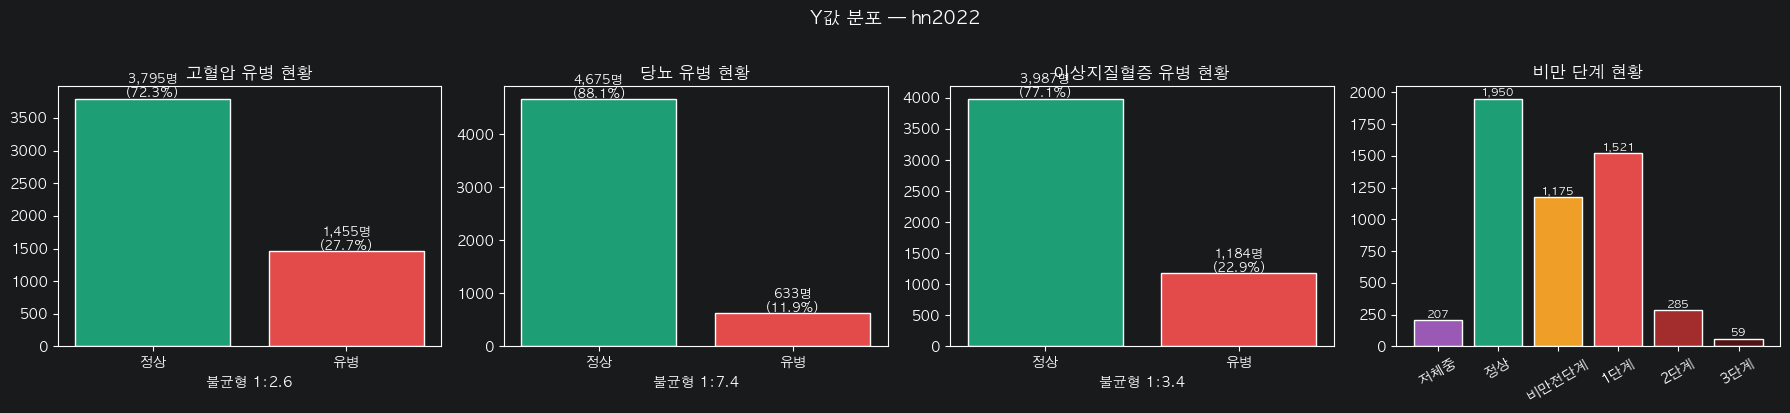

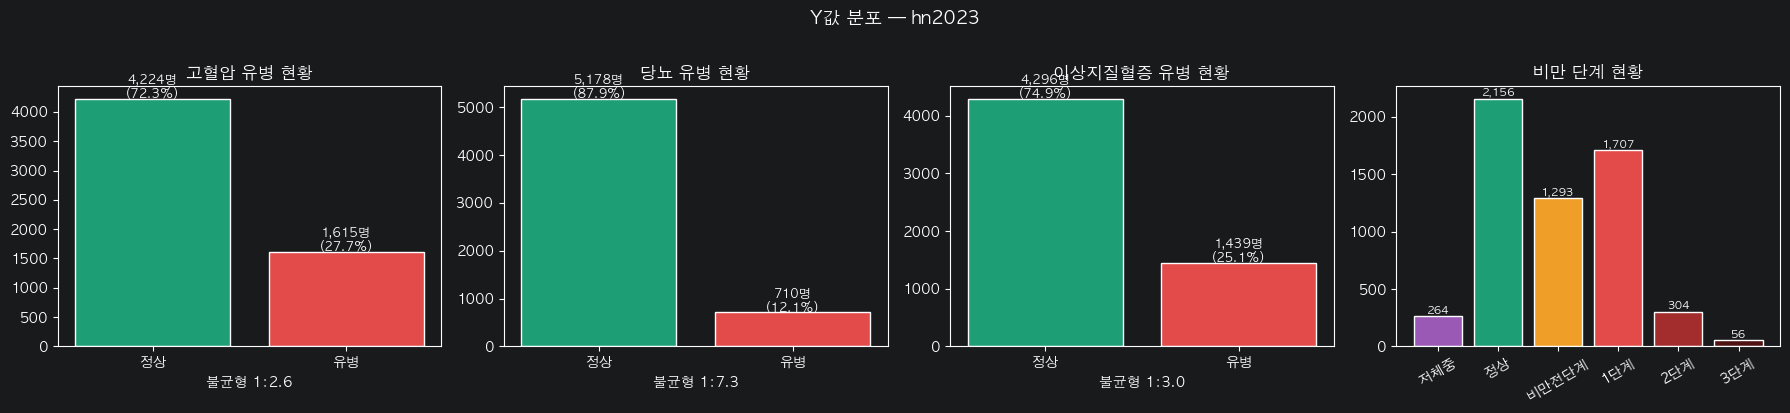

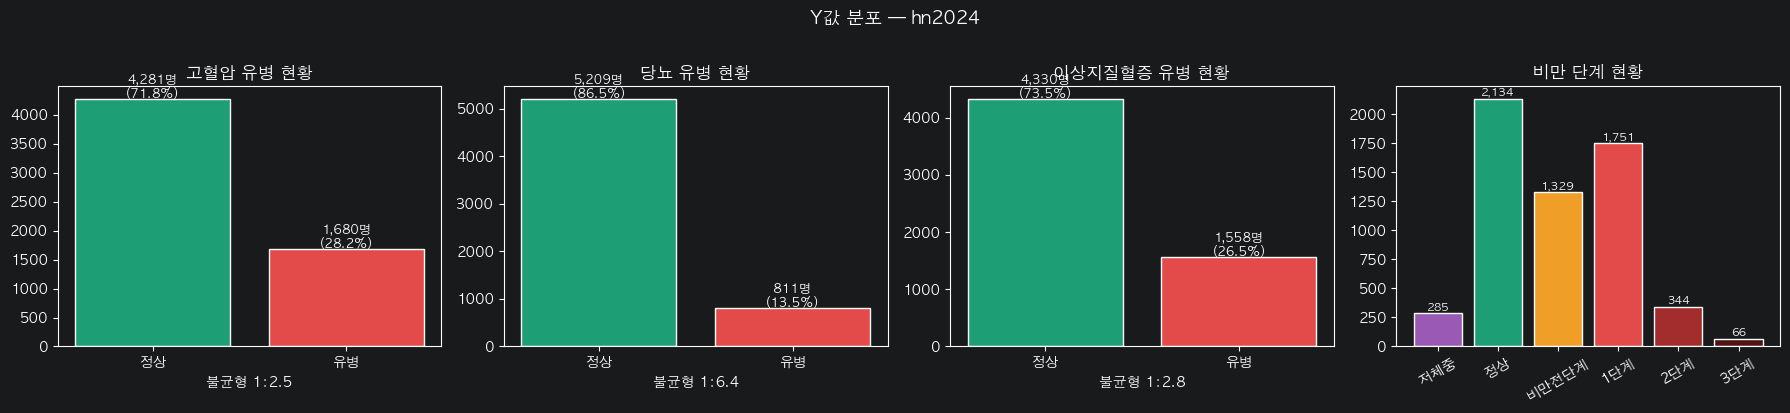

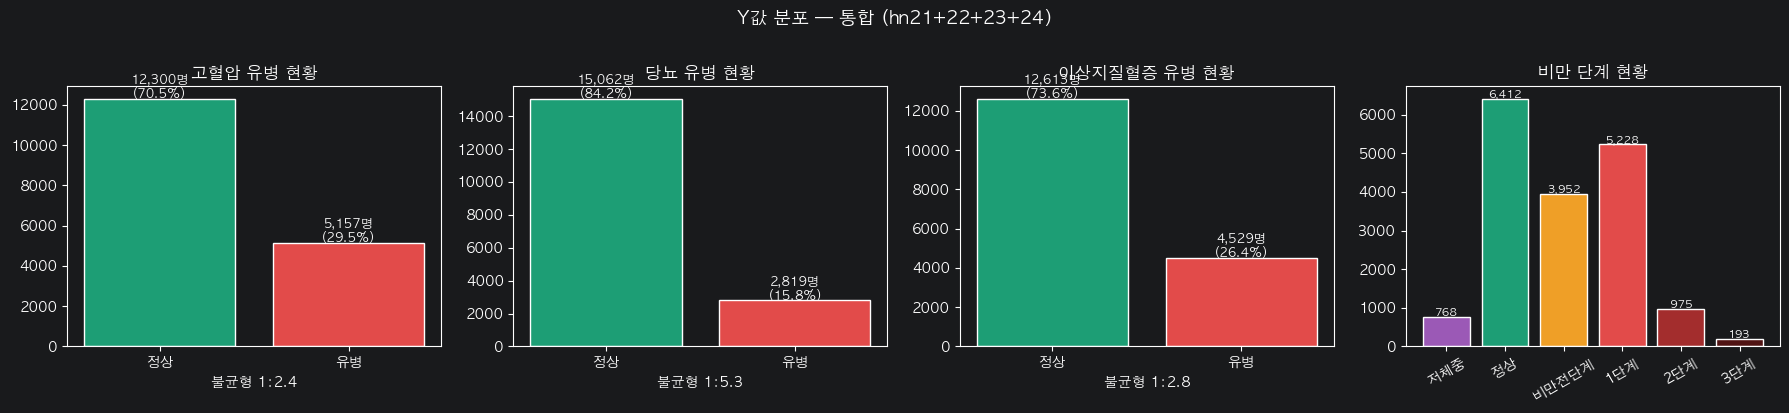

In [24]:
def plot_y_dist(data, title_suffix=""):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for ax, col, title in zip(
        axes[:3],
        ["고혈압유병","당뇨유병","이상지질혈증유병"],
        ["고혈압","당뇨","이상지질혈증"]
    ):
        vc = data[col].value_counts().sort_index()
        n_total = vc.sum()
        bars = ax.bar(["정상","유병"], vc.values, color=["#1D9E75","#E24B4A"], edgecolor="white")
        ax.set_title(f"{title} 유병 현황")
        for bar, val in zip(bars, vc.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                    f"{val:,}명\n({val/n_total*100:.1f}%)", ha="center", fontsize=9)
        n1=vc.get(1,0); n0=vc.get(0,0)
        ax.set_xlabel(f"불균형 1:{n0/n1:.1f}" if n1>0 else "")

    obe = data["비만단계"].value_counts().sort_index().dropna()
    obe_labels = {1:"저체중",2:"정상",3:"비만전단계",4:"1단계",5:"2단계",6:"3단계"}
    obe.index = [obe_labels.get(int(i), str(i)) for i in obe.index]
    axes[3].bar(obe.index, obe.values,
                color=["#9B59B6","#1D9E75","#EF9F27","#E24B4A","#A32D2D","#501313"],
                edgecolor="white")
    axes[3].set_title("비만 단계 현황")
    axes[3].tick_params(axis="x", rotation=30)
    for i, v in enumerate(obe.values):
        axes[3].text(i, v+20, f"{v:,}", ha="center", fontsize=8)

    plt.suptitle(f"Y값 분포 {title_suffix}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

# 연도별 따로
for year in [2021,2022, 2023, 2024]:
    plot_y_dist(df[df["연도"]==year], f"— hn{year}")

# 전체 합쳐서
plot_y_dist(df, "— 통합 (hn21+22+23+24)")

## 4. 연속형 변수 분포

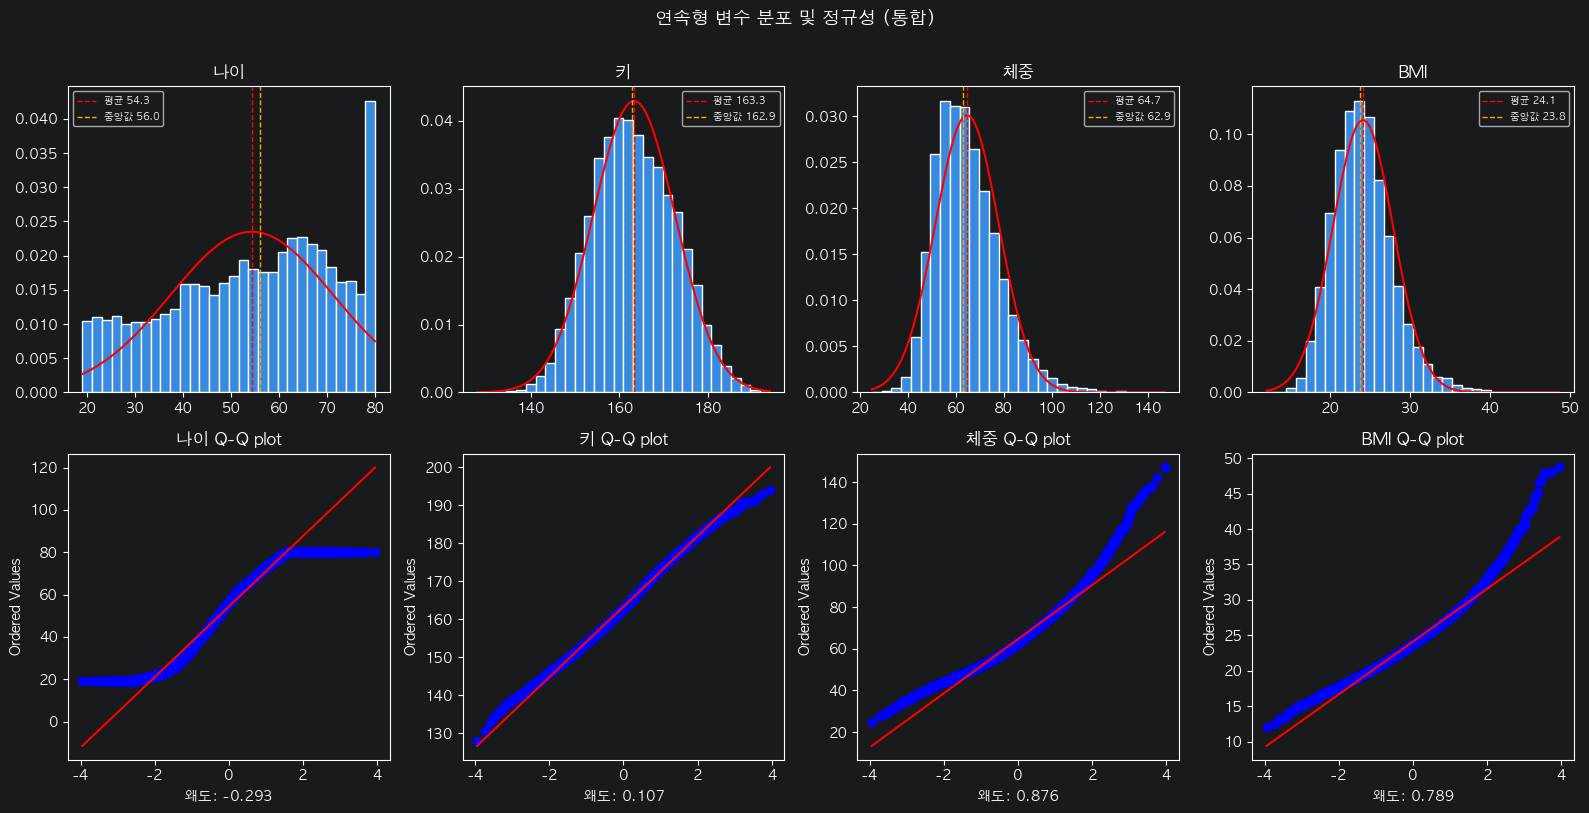

In [25]:
cont_cols = ["나이","키","체중","BMI"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for j, col in enumerate(cont_cols):
    data = df[col].dropna()
    mu, std = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    axes[0][j].hist(data, bins=30, color="#378ADD", edgecolor="white", density=True)
    axes[0][j].plot(x, stats.norm.pdf(x, mu, std), "r-", lw=1.5)
    axes[0][j].axvline(mu, color="red", ls="--", lw=1, label=f"평균 {mu:.1f}")
    axes[0][j].axvline(data.median(), color="orange", ls="--", lw=1, label=f"중앙값 {data.median():.1f}")
    axes[0][j].set_title(col); axes[0][j].legend(fontsize=7)
    stats.probplot(data, dist="norm", plot=axes[1][j])
    axes[1][j].set_title(f"{col} Q-Q plot")
    axes[1][j].set_xlabel(f"왜도: {data.skew():.3f}")

plt.suptitle("연속형 변수 분포 및 정규성 (통합)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 5. 범주형 변수 분포

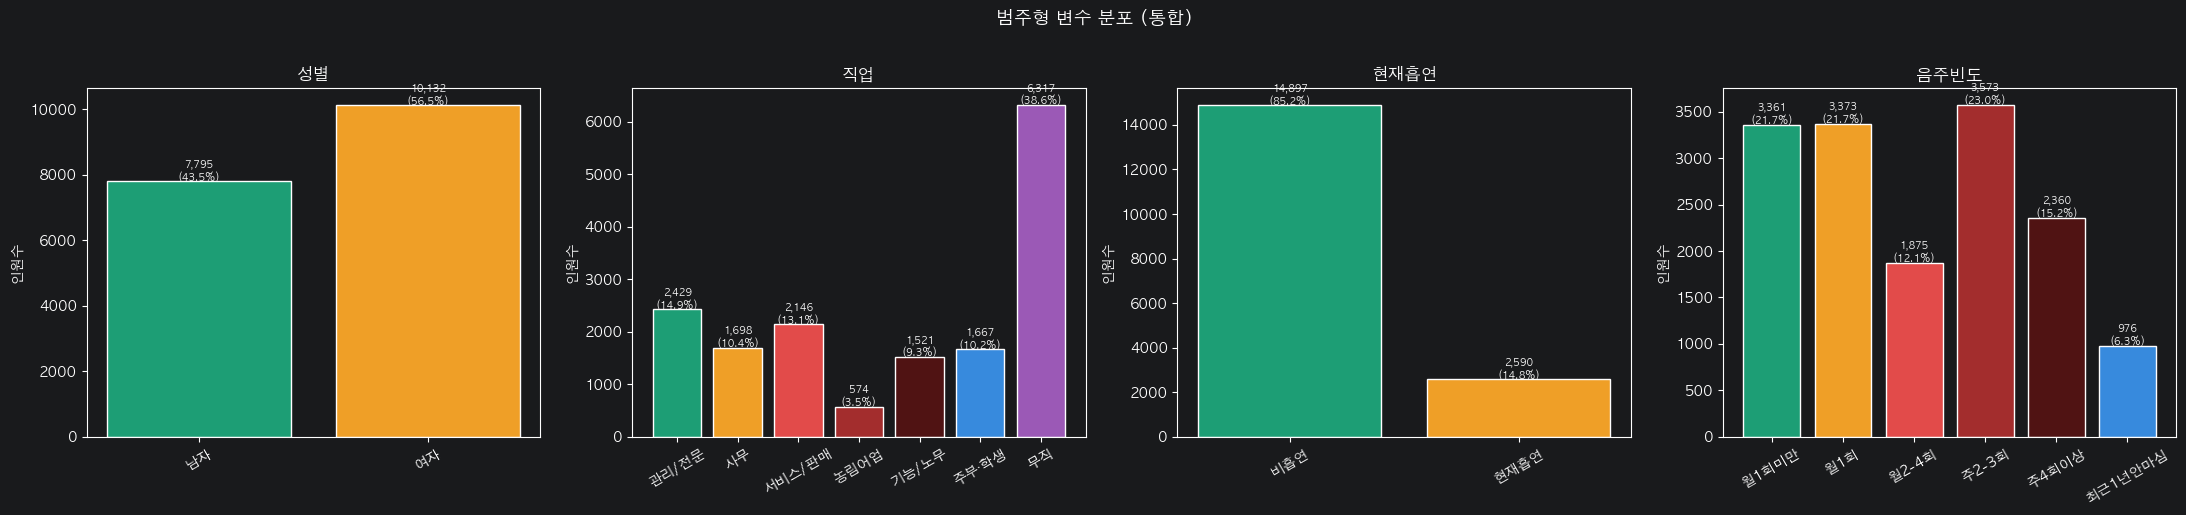

In [26]:
cat_cols = {
    "성별":     {1:"남자", 2:"여자"},
    "직업":     {1:"관리/전문",2:"사무",3:"서비스/판매",4:"농림어업",5:"기능/노무",6:"주부·학생",7:"무직"},
    "현재흡연": {0:"비흡연", 1:"현재흡연"},
    "음주빈도": {0:"비음주",1:"월1회미만",2:"월1회",3:"월2-4회",4:"주2-3회",5:"주4회이상",6:"최근1년안마심"},
}
colors = ["#1D9E75","#EF9F27","#E24B4A","#A32D2D","#501313","#378ADD","#9B59B6","#2ECC71"]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (col, labels) in zip(axes, cat_cols.items()):
    vc = df[col].value_counts(dropna=True).sort_index()
    vc = vc[vc.index.isin(labels.keys())]
    new_index = [labels.get(i, str(i)) for i in vc.index]
    pct = (vc/vc.sum()*100).round(1)
    bars = ax.bar(new_index, vc.values, color=colors[:len(vc)], edgecolor="white")
    ax.set_title(col, fontsize=12); ax.set_ylabel("인원수"); ax.tick_params(axis="x", rotation=30)
    for bar, val, p in zip(bars, vc.values, pct.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                f"{val:,}\n({p}%)", ha="center", fontsize=7)

plt.suptitle("범주형 변수 분포 (통합)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 6. Y값별 연속형 비교 (boxplot)

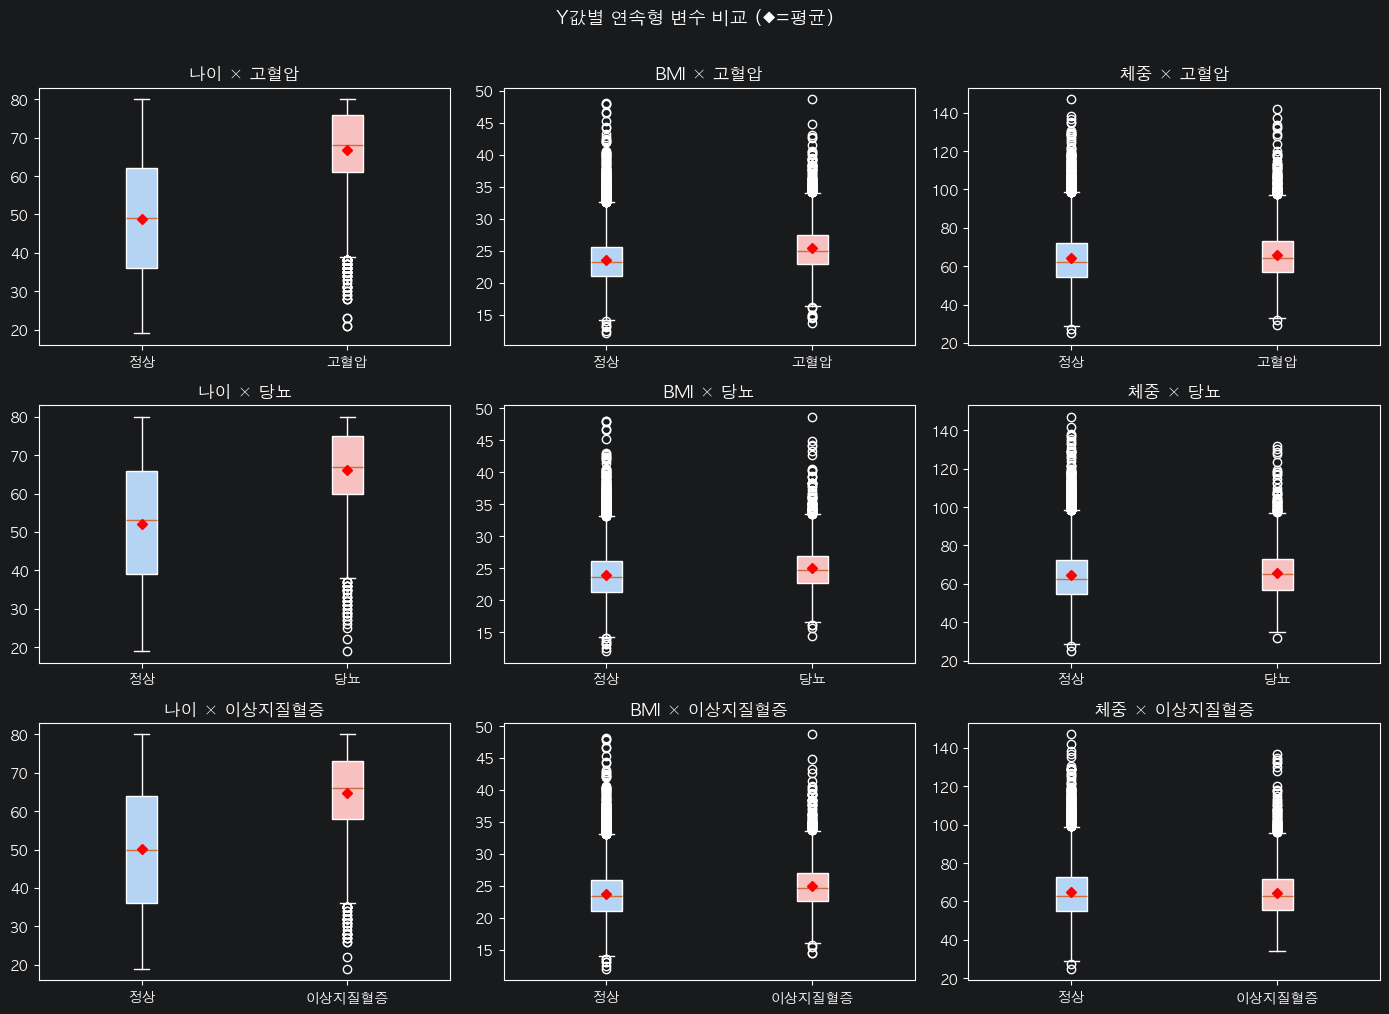

In [27]:
y_vars = {"고혈압유병":"고혈압", "당뇨유병":"당뇨", "이상지질혈증유병":"이상지질혈증"}
x_vars = ["나이","BMI","체중"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, (y_col, y_label) in enumerate(y_vars.items()):
    for j, x_col in enumerate(x_vars):
        d0 = df[df[y_col]==0][x_col].dropna()
        d1 = df[df[y_col]==1][x_col].dropna()
        bp = axes[i][j].boxplot([d0,d1], labels=["정상",y_label], patch_artist=True)
        bp["boxes"][0].set_facecolor("#B5D4F4")
        bp["boxes"][1].set_facecolor("#F7C1C1")
        axes[i][j].set_title(f"{x_col} × {y_label}")
        for k, d in enumerate([d0,d1]):
            axes[i][j].plot(k+1, d.mean(), "D", color="red", ms=5, zorder=5)

plt.suptitle("Y값별 연속형 변수 비교 (◆=평균)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 7. 결측률 분석

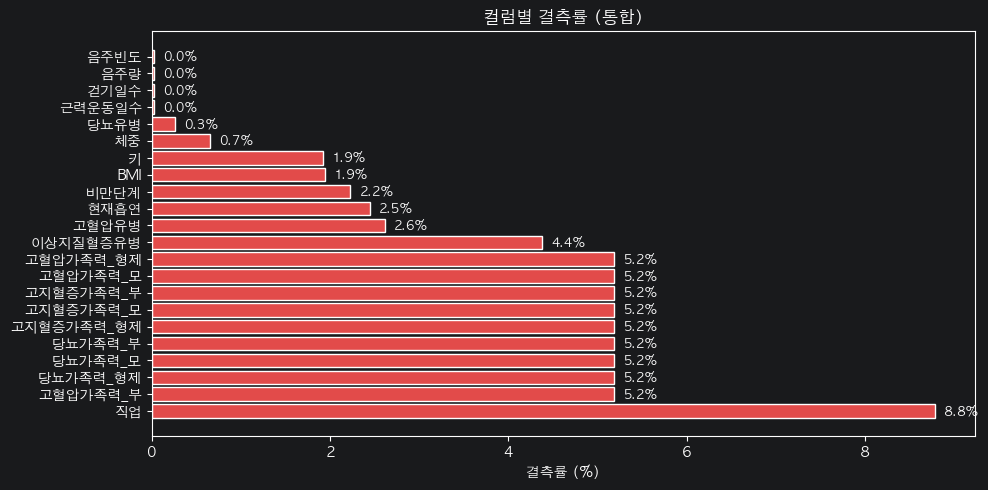

=== 결측률 상세 ===
직업            8.79
고혈압가족력_부      5.19
당뇨가족력_형제      5.19
당뇨가족력_모       5.19
당뇨가족력_부       5.19
고지혈증가족력_형제    5.19
고지혈증가족력_모     5.19
고지혈증가족력_부     5.19
고혈압가족력_모      5.19
고혈압가족력_형제     5.19
이상지질혈증유병      4.38
고혈압유병         2.62
현재흡연          2.45
비만단계          2.23
BMI           1.94
키             1.92
체중            0.66
당뇨유병          0.26
근력운동일수        0.03
걷기일수          0.03
음주량           0.03
음주빈도          0.03
dtype: float64


In [28]:
miss_pct = (df.isnull().sum()/len(df)*100).round(2)
miss_pct = miss_pct[miss_pct>0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(miss_pct.index, miss_pct.values, color="#E24B4A", edgecolor="white")
ax.set_xlabel("결측률 (%)"); ax.set_title("컬럼별 결측률 (통합)")
for bar, val in zip(bars, miss_pct.values):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()
print("=== 결측률 상세 ===")
print(miss_pct)

## 8. 가족력 보유율

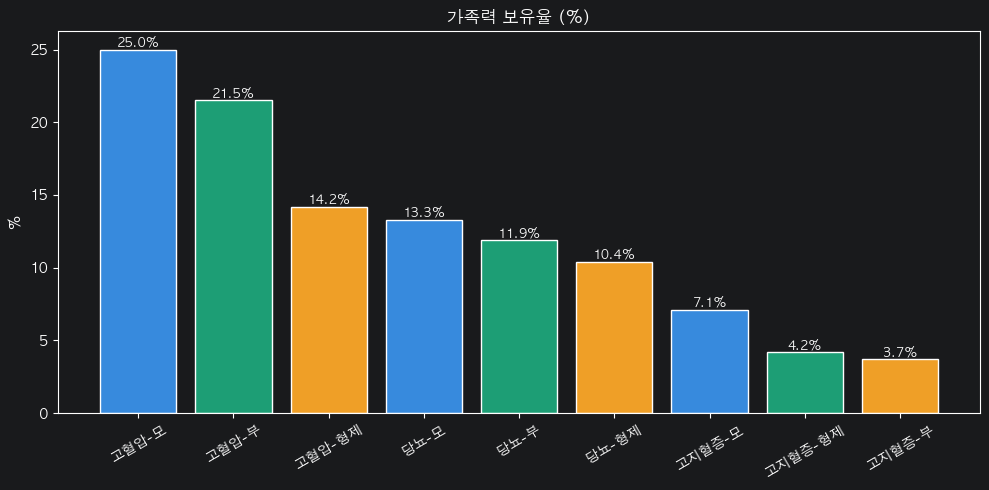

In [29]:
fh_cols = {
    "고혈압가족력_부":"고혈압-부","고혈압가족력_모":"고혈압-모","고혈압가족력_형제":"고혈압-형제",
    "당뇨가족력_부":"당뇨-부","당뇨가족력_모":"당뇨-모","당뇨가족력_형제":"당뇨-형제",
    "고지혈증가족력_부":"고지혈증-부","고지혈증가족력_모":"고지혈증-모","고지혈증가족력_형제":"고지혈증-형제",
}
fh_rate = {}
for col, label in fh_cols.items():
    vc = df[col].value_counts(dropna=True)
    n1 = vc.get(1.0, vc.get(1, 0))
    fh_rate[label] = round(n1/vc.sum()*100, 1) if vc.sum()>0 else 0

fh_series = pd.Series(fh_rate).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fh_series.index, fh_series.values,
              color=["#378ADD","#1D9E75","#EF9F27"]*3, edgecolor="white")
ax.set_title("가족력 보유율 (%)"); ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=30)
for bar, val in zip(bars, fh_series.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f"{val}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## 9. 연도별 유병률 추이

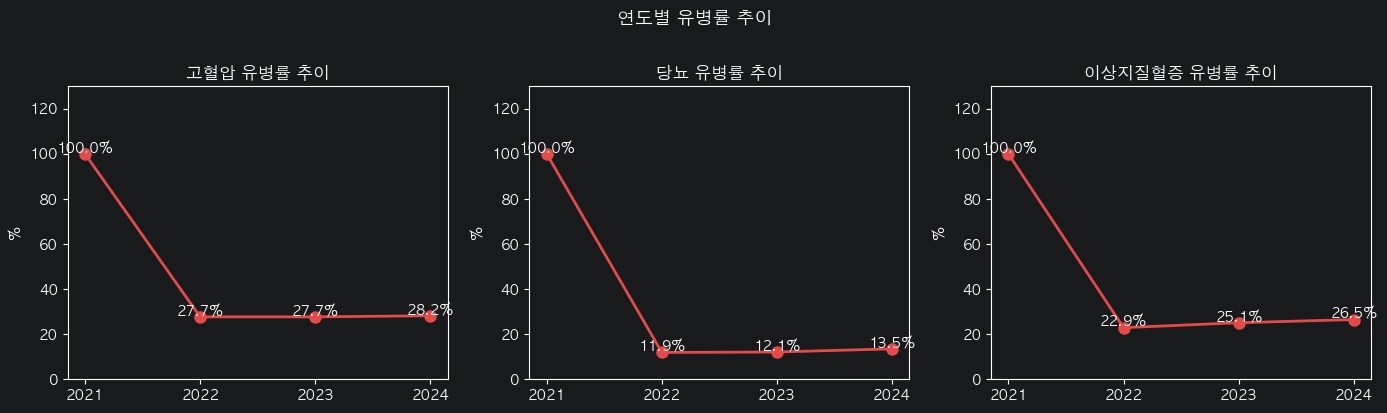

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
y_info = [("고혈압유병","고혈압"),("당뇨유병","당뇨"),("이상지질혈증유병","이상지질혈증")]

for ax, (col, label) in zip(axes, y_info):
    trend = df.groupby("연도")[col].apply(
        lambda x: (x==1).sum()/x.notna().sum()*100
    ).round(1)
    ax.plot(trend.index, trend.values, "o-", color="#E24B4A", lw=2, ms=8)
    ax.set_title(f"{label} 유병률 추이"); ax.set_ylabel("%"); ax.set_xticks(trend.index)
    for x_val, y_val in zip(trend.index, trend.values):
        ax.text(x_val, y_val+0.3, f"{y_val:.1f}%", ha="center", fontsize=10)
    ax.set_ylim(0, trend.max()*1.3)

plt.suptitle("연도별 유병률 추이", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 10. 상관관계 히트맵

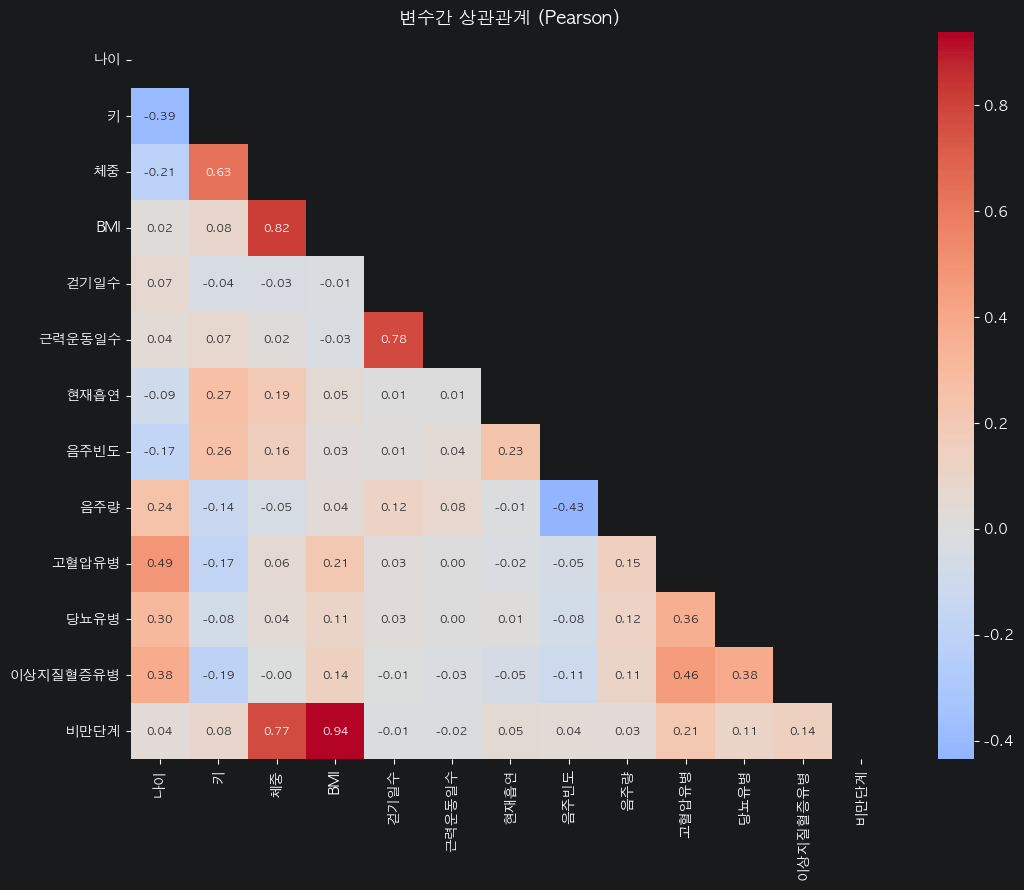

In [31]:
corr_cols = ["나이","키","체중","BMI","걷기일수","근력운동일수",
             "현재흡연","음주빈도","음주량",
             "고혈압유병","당뇨유병","이상지질혈증유병","비만단계"]

df_corr = df[corr_cols].copy()
df_corr["음주빈도"] = df_corr["음주빈도"].where(~df_corr["음주빈도"].isin([8,9]), other=np.nan)

corr = df_corr.corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, annot_kws={"size":8})
ax.set_title("변수간 상관관계 (Pearson)", fontsize=13)
plt.tight_layout(); plt.show()